# Week 4 - Circuit Tracing Homonym Disambiguation in Gemma 2B

Goal: use `circuit-tracer` to inspect how Gemma 2B maps the **same surface word** to different meanings depending on context, and where those internal mappings start to diverge.

This notebook studies **homonyms**, not homophones. The setup is cleaner for mechanistic analysis because both prompts target the **same output token**, while the surrounding context points to different senses.

Workflow:
- audit several candidate homonym words to make sure the intended next token is actually supported in both senses
- select the strongest homonym automatically, unless overridden manually
- trace one prompt for each sense with the same forced target token id
- compare the two graphs to see how much of the circuit is shared and where the mappings branch

The defaults are conservative so the notebook remains usable on CPU. If the model and transcoders are already cached, the later cells should run without modification.

In [1]:
from collections import defaultdict
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.graph import (
    compute_edge_influence,
    compute_node_influence,
    find_threshold,
    prune_graph,
)
from circuit_tracer.utils.caching import save_transcoders_to_cache
from circuit_tracer.utils.create_graph_files import create_graph_files
from circuit_tracer.utils.demo_utils import get_top_features


/Volumes/Crucial X8/repos/interpretabie_llms/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [ ]:
# Uncomment this if Gemma weights are not already accessible in your environment.
# from huggingface_hub import notebook_login
# notebook_login()


In [2]:
# Avoid MPS for Gemma + circuit-tracer. CPU is slower but much more predictable.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if DEVICE.type == "cuda" else torch.float32
OFFLOAD = "cpu" if DEVICE.type == "cuda" else None

MODEL_NAME = "google/gemma-2-2b"
TRANSCODER_SET = "mntss/gemma-scope-transcoders"
BACKEND = "transformerlens"
CACHE_TRANSCODERS_FIRST = False
USE_LAZY_TRANSCODERS = True

# Set HOMONYM_OVERRIDE to one of the keys below if you want to force a specific word.
HOMONYM_OVERRIDE = None
AUTO_SELECT_BEST_HOMONYM = True

CANDIDATE_HOMONYMS = {
    "bank": {
        "target": " bank",
        "senses": {
            "finance": {
                "gloss": "financial institution",
                "prompt": "She deposited her paycheck at the",
            },
            "river": {
                "gloss": "river edge",
                "prompt": "They sat on the grassy river",
            },
        },
    },
    "bat": {
        "target": " bat",
        "senses": {
            "sports": {
                "gloss": "baseball equipment",
                "prompt": "He swung the wooden",
            },
            "animal": {
                "gloss": "flying mammal",
                "prompt": "At dusk, a small",
            },
        },
    },
    "bark": {
        "target": " bark",
        "senses": {
            "dog": {
                "gloss": "dog sound",
                "prompt": "The dog began to",
            },
            "tree": {
                "gloss": "tree covering",
                "prompt": "The rough outer layer of the tree is",
            },
        },
    },
    "watch": {
        "target": " watch",
        "senses": {
            "noun": {
                "gloss": "timepiece",
                "prompt": "She checked the time on her",
            },
            "verb": {
                "gloss": "pay attention",
                "prompt": "Please carefully",
            },
        },
    },
}

TOP_LOGITS_TO_SHOW = 10
MAX_TARGET_RANK_FOR_GOOD_CASE = TOP_LOGITS_TO_SHOW
MAX_N_LOGITS = 1
DESIRED_LOGIT_PROB = 0.95
TOP_N_COMPARE = 40
BATCH_SIZE = 128 if DEVICE.type == "cuda" else 16
MAX_FEATURE_NODES = 2048 if DEVICE.type == "cuda" else 512
NODE_THRESHOLD = 0.80
EDGE_THRESHOLD = 0.98

OUTPUT_DIR = Path(".")
SUMMARY_PATH = OUTPUT_DIR / "week4_gemma_homonym_circuit_summary.pt"
HOMONYM_AUDIT_FIG_PATH = OUTPUT_DIR / "week4_homonym_candidate_audit.png"
LAYER_FIG_PATH = OUTPUT_DIR / "week4_homonym_selected_word_layer_influence.png"
GRAPH_EXPORT_DIR = (OUTPUT_DIR / "week4_homonym_graph_files").resolve()

print({
    "device": str(DEVICE),
    "dtype": str(DTYPE),
    "offload": OFFLOAD,
    "transcoder_set": TRANSCODER_SET,
    "homonym_override": HOMONYM_OVERRIDE,
    "auto_select_best_homonym": AUTO_SELECT_BEST_HOMONYM,
    "candidate_homonyms": list(CANDIDATE_HOMONYMS),
    "batch_size": BATCH_SIZE,
    "max_feature_nodes": MAX_FEATURE_NODES,
})


{'device': 'cpu', 'dtype': 'torch.float32', 'offload': None, 'transcoder_set': 'mntss/gemma-scope-transcoders', 'homonym_override': None, 'auto_select_best_homonym': True, 'candidate_homonyms': ['bank', 'bat', 'bark', 'watch'], 'batch_size': 16, 'max_feature_nodes': 512}


In [3]:
if CACHE_TRANSCODERS_FIRST:
    cache_start = time.time()
    cache_path = save_transcoders_to_cache(
        TRANSCODER_SET,
        sequential=True,
        device=torch.device("cpu"),
        dtype=torch.float32,
    )
    print(f"Cached transcoders to {cache_path} in {time.time() - cache_start:.1f}s")
else:
    print("Skipping transcoder caching. Set CACHE_TRANSCODERS_FIRST = True for a one-time pre-cache step.")


Skipping transcoder caching. Set CACHE_TRANSCODERS_FIRST = True for a one-time pre-cache step.


In [4]:
load_start = time.time()

model = ReplacementModel.from_pretrained(
    model_name=MODEL_NAME,
    transcoder_set=TRANSCODER_SET,
    backend=BACKEND,
    device=DEVICE,
    dtype=DTYPE,
    lazy_encoder=USE_LAZY_TRANSCODERS,
    lazy_decoder=USE_LAZY_TRANSCODERS,
)
model.eval()

print(f"Loaded {MODEL_NAME} on {DEVICE} with backend={BACKEND} in {time.time() - load_start:.1f}s")
print(f"Model layers: {model.cfg.n_layers}, heads: {model.cfg.n_heads}, d_model: {model.cfg.d_model}")
print(f"Transcoder scan: {model.scan}")


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
Loaded google/gemma-2-2b on cpu with backend=transformerlens in 58.4s
Model layers: 26, heads: 8, d_model: 2304
Transcoder scan: mntss/gemma-scope-transcoders


## Candidate Audit

Before tracing any homonym, check whether Gemma naturally supports the shared target token in **both** senses. For each candidate word, the cell below measures:

- whether the target spelling is a clean single-token target
- the next-token rank of that target in each sense-specific prompt
- the probability assigned to that target in each prompt

That matters because the circuit story is much stronger when the model is already leaning toward the intended word in both meanings.

In [5]:
def token_pieces(token_ids):
    return [model.tokenizer.decode([int(token_id)]) for token_id in token_ids]


def prompt_top_tokens(prompt: str, top_k: int = TOP_LOGITS_TO_SHOW):
    token_ids = model.to_tokens(prompt).to(DEVICE)
    with torch.inference_mode():
        logits = model(token_ids, return_type="logits")
    probs = logits[0, -1].softmax(dim=-1).detach().cpu()
    top_p, top_i = probs.topk(top_k)
    top_tokens = [
        (model.tokenizer.decode([int(idx)]), float(prob), int(idx))
        for idx, prob in zip(top_i, top_p)
    ]
    return probs, top_tokens


homonym_audits = {}

for word, word_spec in CANDIDATE_HOMONYMS.items():
    target_ids = model.tokenizer.encode(word_spec["target"], add_special_tokens=False)
    target_pieces = token_pieces(target_ids)
    member_reports = {}

    print(f"\n=== HOMONYM: {word} ===")
    print(f"Expected target: {word_spec['target']!r}")
    print(f"Token count: {len(target_ids)}")
    print(f"Token pieces: {target_pieces}")

    for sense_name, sense_spec in word_spec["senses"].items():
        probs, top_tokens = prompt_top_tokens(sense_spec["prompt"])
        expected_id = int(target_ids[0])
        expected_prob = float(probs[expected_id])
        expected_rank = int((probs > probs[expected_id]).sum().item()) + 1
        single_token_target = len(target_ids) == 1

        member_reports[sense_name] = {
            "gloss": sense_spec["gloss"],
            "prompt": sense_spec["prompt"],
            "target": word_spec["target"],
            "target_ids": target_ids,
            "target_pieces": target_pieces,
            "expected_id": expected_id,
            "expected_prob": expected_prob,
            "expected_rank": expected_rank,
            "single_token_target": single_token_target,
            "prompt_tokens": model.to_str_tokens(sense_spec["prompt"]),
            "top_next_tokens": top_tokens,
        }

        print(f"\nPrompt [{sense_name} | {sense_spec['gloss']}]: {sense_spec['prompt']}")
        print(f"Prompt tokens: {model.to_str_tokens(sense_spec['prompt'])}")
        print(
            f"Expected target {word_spec['target']!r}: rank={expected_rank}, prob={expected_prob:.4f}, "
            f"single_token_target={single_token_target}"
        )
        for rank, (token, prob, vocab_idx) in enumerate(top_tokens, start=1):
            print(f"  {rank:>2}. {token!r:<12} prob={prob:.4f}  vocab_id={vocab_idx}")

    probs_for_word = [report["expected_prob"] for report in member_reports.values()]
    ranks_for_word = [report["expected_rank"] for report in member_reports.values()]
    both_single_token = all(report["single_token_target"] for report in member_reports.values())
    both_in_top_k = all(rank <= MAX_TARGET_RANK_FOR_GOOD_CASE for rank in ranks_for_word)

    homonym_audits[word] = {
        "target": word_spec["target"],
        "member_reports": member_reports,
        "mean_target_prob": sum(probs_for_word) / len(probs_for_word),
        "min_target_prob": min(probs_for_word),
        "worst_rank": max(ranks_for_word),
        "both_single_token": both_single_token,
        "both_in_top_k": both_in_top_k,
    }

word_names = list(homonym_audits)
sense_names = list(next(iter(CANDIDATE_HOMONYMS.values()))["senses"].keys())
x = torch.arange(len(word_names))
bar_width = 0.35
left_sense, right_sense = sense_names
left_scores = [homonym_audits[word]["member_reports"][left_sense]["expected_prob"] for word in word_names]
right_scores = [homonym_audits[word]["member_reports"][right_sense]["expected_prob"] for word in word_names]

fig, ax = plt.subplots(figsize=(12, 4.5))
bars_left = ax.bar(x - bar_width / 2, left_scores, width=bar_width, color="#1f77b4", label=left_sense)
bars_right = ax.bar(x + bar_width / 2, right_scores, width=bar_width, color="#ff7f0e", label=right_sense)
ax.set_xticks(x)
ax.set_xticklabels(word_names, rotation=20, ha="right")
ax.set_ylabel("Expected target token probability")
ax.set_title("Homonym candidate audit before circuit tracing")
ax.legend()
for bars, sense_name in [(bars_left, left_sense), (bars_right, right_sense)]:
    for bar, word in zip(bars, word_names):
        report = homonym_audits[word]["member_reports"][sense_name]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"r{report['expected_rank']}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
fig.tight_layout()
fig.savefig(HOMONYM_AUDIT_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved homonym audit plot to {HOMONYM_AUDIT_FIG_PATH}")



=== HOMONYM: bank ===
Expected target: ' bank'
Token count: 1
Token pieces: [' bank']

Prompt [finance | financial institution]: She deposited her paycheck at the
Prompt tokens: ['<bos>', 'She', ' deposited', ' her', ' paycheck', ' at', ' the']
Expected target ' bank': rank=1, prob=0.7649, single_token_target=True
   1. ' bank'      prob=0.7649  vocab_id=5681
   2. ' ATM'       prob=0.0339  vocab_id=48868
   3. ' end'       prob=0.0293  vocab_id=1580
   4. ' local'     prob=0.0241  vocab_id=2813
   5. ' branch'    prob=0.0108  vocab_id=12832
   6. ' credit'    prob=0.0107  vocab_id=6927
   7. ' beginning' prob=0.0104  vocab_id=7489
   8. ' post'      prob=0.0094  vocab_id=2053
   9. ' same'      prob=0.0087  vocab_id=1809
  10. ' Bank'      prob=0.0066  vocab_id=6226

Prompt [river | river edge]: They sat on the grassy river
Prompt tokens: ['<bos>', 'They', ' sat', ' on', ' the', ' grassy', ' river']
Expected target ' bank': rank=2, prob=0.2343, single_token_target=True
   1. 'bank'  

KeyError: 'finance'

In [6]:
ranked_words = sorted(
    homonym_audits.items(),
    key=lambda item: (
        int(item[1]["both_single_token"]),
        int(item[1]["both_in_top_k"]),
        item[1]["min_target_prob"],
        -item[1]["worst_rank"],
    ),
    reverse=True,
)
recommended_word = ranked_words[0][0]

if HOMONYM_OVERRIDE is not None:
    SELECTED_WORD = HOMONYM_OVERRIDE
elif AUTO_SELECT_BEST_HOMONYM:
    SELECTED_WORD = recommended_word
else:
    SELECTED_WORD = "bank"

selected_word_spec = CANDIDATE_HOMONYMS[SELECTED_WORD]
selected_audit = homonym_audits[SELECTED_WORD]
SENSE_NAMES = list(selected_word_spec["senses"].keys())
LEFT_SENSE, RIGHT_SENSE = SENSE_NAMES
SENSE_DISPLAY_NAMES = {
    sense_name: selected_word_spec["senses"][sense_name]["gloss"]
    for sense_name in SENSE_NAMES
}
TARGET_TOKEN = selected_word_spec["target"]
TARGET_TOKEN_ID = int(selected_audit["member_reports"][LEFT_SENSE]["expected_id"])
WORD_SLUG = f"week4-gemma-homonym-{SELECTED_WORD}"

print("Ranked homonyms:")
for word, audit in ranked_words:
    print(
        f"  {word:<8} min_target_prob={audit['min_target_prob']:.4f} "
        f"worst_rank={audit['worst_rank']} both_single_token={audit['both_single_token']}"
    )

print(f"\nSelected homonym: {SELECTED_WORD}")
print(f"Forced target token: {TARGET_TOKEN!r} (id={TARGET_TOKEN_ID})")
for sense_name in SENSE_NAMES:
    report = selected_audit['member_reports'][sense_name]
    print(
        f"  {sense_name:<8} gloss={report['gloss']!r} "
        f"rank={report['expected_rank']} prob={report['expected_prob']:.4f}"
    )


Ranked homonyms:
  bank     min_target_prob=0.2343 worst_rank=2 both_single_token=True
  bark     min_target_prob=0.0121 worst_rank=8 both_single_token=True
  watch    min_target_prob=0.0021 worst_rank=21 both_single_token=True
  bat      min_target_prob=0.0001 worst_rank=286 both_single_token=True

Selected homonym: bank
Forced target token: ' bank' (id=5681)
  finance  gloss='financial institution' rank=1 prob=0.7649
  river    gloss='river edge' rank=2 prob=0.2343


## Attribution Graphs

The next cells trace the same target word in two different contexts. Because the final output token is identical, any circuit difference we find reflects **sense disambiguation**, not a trivial change in the output spelling.

In [7]:
def attribute_sense(sense_name: str):
    prompt = selected_word_spec["senses"][sense_name]["prompt"]
    attribution_target_ids = torch.tensor([TARGET_TOKEN_ID], dtype=torch.long, device=DEVICE)
    print(
        f"\nTracing {sense_name} sense with forced target token {TARGET_TOKEN!r} "
        f"(id={TARGET_TOKEN_ID})"
    )
    graph = attribute(
        prompt,
        model,
        attribution_targets=attribution_target_ids,
        max_n_logits=MAX_N_LOGITS,
        desired_logit_prob=DESIRED_LOGIT_PROB,
        batch_size=BATCH_SIZE,
        max_feature_nodes=MAX_FEATURE_NODES,
        offload=OFFLOAD,
        verbose=True,
    )
    graph_path = OUTPUT_DIR / f"{WORD_SLUG}-{sense_name}.pt"
    graph.to_pt(str(graph_path))
    print(f"Saved graph to {graph_path}")
    return graph


graphs = {sense_name: attribute_sense(sense_name) for sense_name in SENSE_NAMES}


Phase 0: Precomputing activations and vectors



Tracing finance sense with forced target token ' bank' (id=5681)


Precomputation completed in 48.05s
Found 5606 active features
Phase 1: Running forward pass
Forward pass completed in 42.49s
Phase 2: Building input vectors
Using 1 specified logit targets with cumulative probability 0.7649
Will include 512 of 5606 feature nodes
Input vectors built in 3.51s
Phase 3: Computing logit attributions
/Volumes/Crucial X8/repos/interpretabie_llms/.venv/lib/python3.13/site-packages/circuit_tracer/attribution/context_transformerlens.py:224: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(
Logit attributions completed in 2.76s
Phase 4: Computing feature attributions
Feature influence computation: 100%|█████████████████████████████████████████████████████████████████████████████| 512/512 [00:10<00:00, 

Saved graph to week4-gemma-homonym-bank-finance.pt

Tracing river sense with forced target token ' bank' (id=5681)


Precomputation completed in 73.04s
Found 5295 active features
Phase 1: Running forward pass
Forward pass completed in 37.33s
Phase 2: Building input vectors
Using 1 specified logit targets with cumulative probability 0.2343
Will include 512 of 5295 feature nodes
Input vectors built in 3.19s
Phase 3: Computing logit attributions
Logit attributions completed in 3.48s
Phase 4: Computing feature attributions
Feature influence computation: 100%|█████████████████████████████████████████████████████████████████████████████| 512/512 [00:08<00:00, 57.88it/s]
Feature attributions completed in 8.85s
Attribution completed in 125.99s


Saved graph to week4-gemma-homonym-bank-river.pt


In [8]:
pruned_sizes = {}
for sense_name, graph in graphs.items():
    node_mask, edge_mask, _ = prune_graph(
        graph,
        node_threshold=NODE_THRESHOLD,
        edge_threshold=EDGE_THRESHOLD,
    )
    pruned_sizes[sense_name] = {
        "nodes": int(node_mask.sum().item()),
        "edges": int(edge_mask.sum().item()),
        "target_logits": [target.token_str for target in graph.logit_targets],
    }
    print(f"\n{sense_name.upper()} GRAPH")
    print(pruned_sizes[sense_name])



FINANCE GRAPH
{'nodes': 270, 'edges': 12661, 'target_logits': [' bank']}

RIVER GRAPH
{'nodes': 275, 'edges': 13343, 'target_logits': [' bank']}


In [9]:
def summarize_feature_influence(graph):
    n_logits = len(graph.logit_targets)
    n_features = len(graph.selected_features)

    logit_weights = torch.zeros(graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device)
    logit_weights[-n_logits:] = graph.logit_probabilities.to(graph.adjacency_matrix.device)

    node_influence = compute_node_influence(graph.adjacency_matrix, logit_weights)
    feature_influence = node_influence[:n_features].cpu()
    selected_features = graph.selected_features.to(graph.active_features.device)
    feature_nodes = graph.active_features[selected_features].cpu()

    layer_scores = torch.zeros(graph.cfg.n_layers, dtype=torch.float32)
    for feature_node, score in zip(feature_nodes, feature_influence):
        layer_scores[int(feature_node[0])] += float(score)

    return feature_nodes, feature_influence, layer_scores


feature_summaries = {}
for sense_name, graph in graphs.items():
    top_features, top_scores = get_top_features(graph, n=12)
    feature_nodes, feature_influence, layer_scores = summarize_feature_influence(graph)
    feature_summaries[sense_name] = {
        "top_features": top_features,
        "top_scores": top_scores,
        "feature_nodes": feature_nodes,
        "feature_influence": feature_influence,
        "layer_scores": layer_scores,
    }

    print(f"\nTOP FEATURES FOR {sense_name.upper()} ({SENSE_DISPLAY_NAMES[sense_name]})")
    for rank, ((layer, pos, feat_idx), score) in enumerate(zip(top_features, top_scores), start=1):
        print(f"  {rank:>2}. layer={layer:>2}  pos={pos:>2}  feature={feat_idx:>6}  influence={score:.6f}")



TOP FEATURES FOR FINANCE (financial institution)
   1. layer=21  pos= 6  feature=  2226  influence=0.054854
   2. layer=25  pos= 6  feature=  9286  influence=0.049360
   3. layer=19  pos= 6  feature=  8421  influence=0.025815
   4. layer=17  pos= 6  feature= 13330  influence=0.023175
   5. layer=22  pos= 6  feature=  4230  influence=0.017584
   6. layer=19  pos= 6  feature=  6103  influence=0.015252
   7. layer=21  pos= 5  feature=  2226  influence=0.013755
   8. layer=17  pos= 5  feature= 13330  influence=0.013316
   9. layer= 0  pos= 5  feature=  7124  influence=0.011764
  10. layer=19  pos= 5  feature=  8421  influence=0.010879
  11. layer= 7  pos= 5  feature=    95  influence=0.009739
  12. layer=22  pos= 6  feature=  5606  influence=0.009730

TOP FEATURES FOR RIVER (river edge)
   1. layer=20  pos= 6  feature= 14197  influence=0.025597
   2. layer=25  pos= 6  feature=  9286  influence=0.011910
   3. layer=24  pos= 6  feature=  2946  influence=0.009738
   4. layer=18  pos= 6  feat

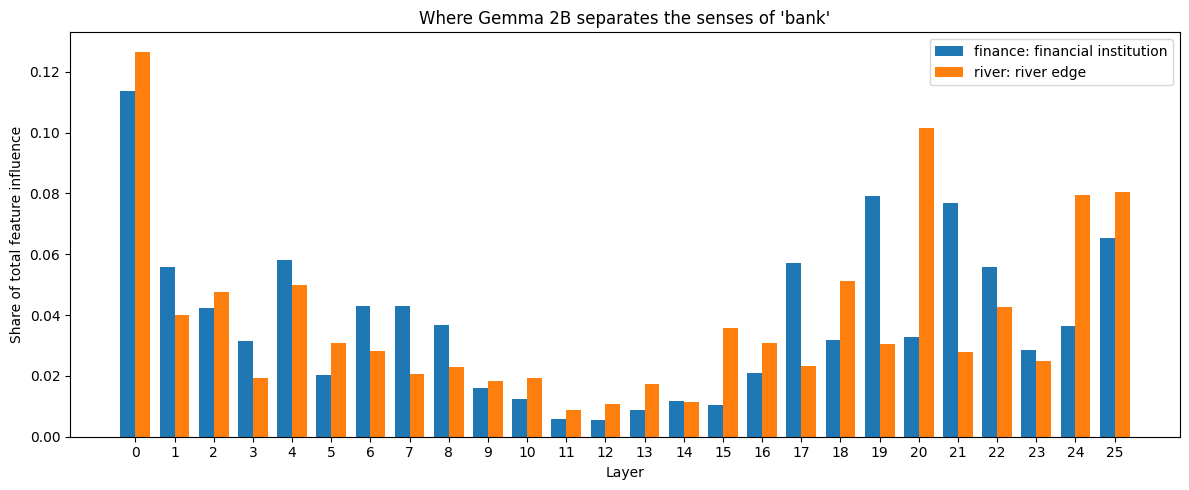

Saved layer influence plot to week4_homonym_selected_word_layer_influence.png


In [10]:
layers = torch.arange(model.cfg.n_layers)
bar_width = 0.38

left_scores = feature_summaries[LEFT_SENSE]["layer_scores"]
right_scores = feature_summaries[RIGHT_SENSE]["layer_scores"]

left_scores = left_scores / left_scores.sum().clamp_min(1e-8)
right_scores = right_scores / right_scores.sum().clamp_min(1e-8)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    layers - bar_width / 2,
    left_scores.numpy(),
    width=bar_width,
    label=f"{LEFT_SENSE}: {SENSE_DISPLAY_NAMES[LEFT_SENSE]}",
    color="#1f77b4",
)
ax.bar(
    layers + bar_width / 2,
    right_scores.numpy(),
    width=bar_width,
    label=f"{RIGHT_SENSE}: {SENSE_DISPLAY_NAMES[RIGHT_SENSE]}",
    color="#ff7f0e",
)
ax.set_xlabel("Layer")
ax.set_ylabel("Share of total feature influence")
ax.set_title(f"Where Gemma 2B separates the senses of '{SELECTED_WORD.strip()}'")
ax.set_xticks(layers)
ax.legend()
fig.tight_layout()
fig.savefig(LAYER_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved layer influence plot to {LAYER_FIG_PATH}")


In [11]:
def layer_feature_signature(features, ignore_position: bool = True):
    if ignore_position:
        return {(layer, feat_idx) for layer, _pos, feat_idx in features}
    return set(features)


def build_feature_vector(feature_nodes, feature_influence):
    feature_vector = defaultdict(float)
    for feature_node, score in zip(feature_nodes.tolist(), feature_influence.tolist()):
        layer, _pos, feat_idx = feature_node
        feature_vector[(int(layer), int(feat_idx))] += float(score)
    return feature_vector


def cosine_similarity(vec_a, vec_b):
    shared_keys = set(vec_a) | set(vec_b)
    dot = sum(vec_a.get(key, 0.0) * vec_b.get(key, 0.0) for key in shared_keys)
    norm_a = sum(value * value for value in vec_a.values()) ** 0.5
    norm_b = sum(value * value for value in vec_b.values()) ** 0.5
    return dot / max(norm_a * norm_b, 1e-12)


def node_descriptor(graph, node_idx: int, *, drop_token_nodes: bool = True):
    n_features = len(graph.selected_features)
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    error_end_idx = n_features + graph.n_pos * graph.cfg.n_layers
    token_end_idx = error_end_idx + n_tokens

    if node_idx < n_features:
        layer, pos, feat_idx = graph.active_features[graph.selected_features[node_idx]].tolist()
        return ("feature", int(layer), int(pos), int(feat_idx))
    if node_idx < error_end_idx:
        layer, pos = divmod(node_idx - n_features, graph.n_pos)
        return ("error", int(layer), int(pos))
    if node_idx < token_end_idx:
        if drop_token_nodes:
            return None
        pos = node_idx - error_end_idx
        token_id = int(graph.input_tokens[pos])
        token_str = model.tokenizer.decode([token_id])
        return ("token", int(pos), token_str)

    return ("logit", "__target__")


def extract_target_edge_vector(graph, *, node_threshold: float, edge_threshold: float, drop_token_nodes: bool = True):
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    target_idx = 0
    logit_weights = torch.zeros(graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device)
    logit_weights[-n_logits + target_idx] = 1.0

    node_influence = compute_node_influence(graph.adjacency_matrix, logit_weights)
    node_mask = node_influence >= find_threshold(node_influence, node_threshold)
    node_mask[-n_logits - n_tokens :] = True

    pruned_matrix = graph.adjacency_matrix.clone()
    pruned_matrix[~node_mask] = 0
    pruned_matrix[:, ~node_mask] = 0

    edge_scores = compute_edge_influence(pruned_matrix, logit_weights)
    edge_mask = edge_scores >= find_threshold(edge_scores.flatten(), edge_threshold)

    old_node_mask = node_mask.clone()
    node_mask[: -n_logits - n_tokens] &= edge_mask[:, : -n_logits - n_tokens].any(0)
    node_mask[:n_features] &= edge_mask[:n_features].any(1)
    while not torch.equal(old_node_mask, node_mask):
        old_node_mask = node_mask.clone()
        edge_mask[~node_mask] = False
        edge_mask[:, ~node_mask] = False
        node_mask[: -n_logits - n_tokens] &= edge_mask[:, : -n_logits - n_tokens].any(0)
        node_mask[:n_features] &= edge_mask[:n_features].any(1)

    error_end_idx = n_features + graph.n_pos * graph.cfg.n_layers
    token_end_idx = error_end_idx + n_tokens
    target_node_idx = token_end_idx + target_idx

    stack = [target_node_idx]
    target_ancestors = {target_node_idx}
    while stack:
        dst = stack.pop()
        for src in torch.nonzero(edge_mask[dst], as_tuple=False).flatten().tolist():
            if src not in target_ancestors:
                target_ancestors.add(src)
                stack.append(src)

    edge_vector = {}
    for dst, src in torch.nonzero(edge_mask, as_tuple=False).tolist():
        if src not in target_ancestors or dst not in target_ancestors:
            continue

        src_desc = node_descriptor(graph, src, drop_token_nodes=drop_token_nodes)
        dst_desc = node_descriptor(graph, dst, drop_token_nodes=drop_token_nodes)
        if src_desc is None or dst_desc is None:
            continue

        edge_key = (src_desc, dst_desc)
        edge_vector[edge_key] = float(edge_scores[dst, src])

    total_weight = sum(edge_vector.values())
    if total_weight > 0:
        edge_vector = {key: value / total_weight for key, value in edge_vector.items()}
    return edge_vector


def weighted_jaccard(vec_a, vec_b):
    shared_keys = set(vec_a) | set(vec_b)
    numerator = sum(min(vec_a.get(key, 0.0), vec_b.get(key, 0.0)) for key in shared_keys)
    denominator = sum(max(vec_a.get(key, 0.0), vec_b.get(key, 0.0)) for key in shared_keys)
    return numerator / max(denominator, 1e-12)


def format_edge(edge_key):
    source, target = edge_key

    def format_node(node):
        node_type = node[0]
        if node_type == "feature":
            _, layer, pos, feat_idx = node
            return f"L{layer} P{pos} F{feat_idx}"
        if node_type == "error":
            _, layer, pos = node
            return f"error(L{layer}, P{pos})"
        return "logit(__target__)"

    return f"{format_node(source)} -> {format_node(target)}"


left_top, _ = get_top_features(graphs[LEFT_SENSE], n=TOP_N_COMPARE)
right_top, _ = get_top_features(graphs[RIGHT_SENSE], n=TOP_N_COMPARE)

left_sig = layer_feature_signature(left_top, ignore_position=True)
right_sig = layer_feature_signature(right_top, ignore_position=True)
shared = sorted(left_sig & right_sig)
only_left = sorted(left_sig - right_sig)
only_right = sorted(right_sig - left_sig)
jaccard = len(shared) / max(1, len(left_sig | right_sig))

left_feature_vector = build_feature_vector(
    feature_summaries[LEFT_SENSE]["feature_nodes"],
    feature_summaries[LEFT_SENSE]["feature_influence"],
)
right_feature_vector = build_feature_vector(
    feature_summaries[RIGHT_SENSE]["feature_nodes"],
    feature_summaries[RIGHT_SENSE]["feature_influence"],
)
feature_cosine = cosine_similarity(left_feature_vector, right_feature_vector)

left_target_edges = extract_target_edge_vector(
    graphs[LEFT_SENSE],
    node_threshold=NODE_THRESHOLD,
    edge_threshold=EDGE_THRESHOLD,
    drop_token_nodes=True,
)
right_target_edges = extract_target_edge_vector(
    graphs[RIGHT_SENSE],
    node_threshold=NODE_THRESHOLD,
    edge_threshold=EDGE_THRESHOLD,
    drop_token_nodes=True,
)
shared_target_edges = sorted(
    set(left_target_edges) & set(right_target_edges),
    key=lambda edge: min(left_target_edges[edge], right_target_edges[edge]),
    reverse=True,
)
target_edge_overlap = weighted_jaccard(left_target_edges, right_target_edges)

layer_delta = left_scores - right_scores
largest_shift_layers = torch.topk(layer_delta.abs(), k=min(5, len(layer_delta))).indices.tolist()

print("Shared (layer, feature_idx) pairs among top features:", len(shared))
print(f"{LEFT_SENSE}-only pairs:", len(only_left))
print(f"{RIGHT_SENSE}-only pairs:", len(only_right))
print(f"Jaccard overlap (ignoring token position): {jaccard:.3f}")
print(f"Weighted cosine over all (layer, feature_idx) influence mass: {feature_cosine:.3f}")
print(f"Internal target-subgraph weighted edge overlap: {target_edge_overlap:.3f}")
print("\nShared examples:", shared[:12])
print(f"\n{LEFT_SENSE}-only examples:", only_left[:12])
print(f"\n{RIGHT_SENSE}-only examples:", only_right[:12])
print(f"\nLargest layer shifts: {largest_shift_layers}")
print("\nTop shared internal edges:")
for edge_key in shared_target_edges[:8]:
    print(
        f"  {format_edge(edge_key)} | {LEFT_SENSE}={left_target_edges[edge_key]:.4f} | {RIGHT_SENSE}={right_target_edges[edge_key]:.4f}"
    )

summary = {
    "model_name": MODEL_NAME,
    "transcoder_set": TRANSCODER_SET,
    "backend": BACKEND,
    "selected_word": SELECTED_WORD,
    "target_token": TARGET_TOKEN,
    "target_token_id": TARGET_TOKEN_ID,
    "config": {
        "device": str(DEVICE),
        "dtype": str(DTYPE),
        "offload": OFFLOAD,
        "max_n_logits": MAX_N_LOGITS,
        "desired_logit_prob": DESIRED_LOGIT_PROB,
        "batch_size": BATCH_SIZE,
        "max_feature_nodes": MAX_FEATURE_NODES,
        "node_threshold": NODE_THRESHOLD,
        "edge_threshold": EDGE_THRESHOLD,
        "top_n_compare": TOP_N_COMPARE,
    },
    "homonym_audits": homonym_audits,
    "senses": selected_word_spec["senses"],
    "pruned_sizes": pruned_sizes,
    "top_features": {
        sense_name: {
            "features": feature_summaries[sense_name]["top_features"],
            "scores": feature_summaries[sense_name]["top_scores"],
            "layer_scores": feature_summaries[sense_name]["layer_scores"],
        }
        for sense_name in feature_summaries
    },
    "overlap_metrics": {
        "top40_feature_jaccard_ignore_position": {
            "shared": shared,
            "only_left": only_left,
            "only_right": only_right,
            "jaccard": jaccard,
        },
        "weighted_feature_vector_cosine": feature_cosine,
        "internal_target_subgraph_weighted_edge_overlap": {
            "metric": "weighted_jaccard",
            "drop_token_nodes": True,
            "left_sense": LEFT_SENSE,
            "right_sense": RIGHT_SENSE,
            "left_edge_count": len(left_target_edges),
            "right_edge_count": len(right_target_edges),
            "shared_edge_count": len(shared_target_edges),
            "weighted_jaccard": target_edge_overlap,
            "top_shared_edges": [
                {
                    "edge": format_edge(edge_key),
                    LEFT_SENSE: left_target_edges[edge_key],
                    RIGHT_SENSE: right_target_edges[edge_key],
                }
                for edge_key in shared_target_edges[:10]
            ],
        },
        "largest_layer_shift_indices": largest_shift_layers,
    },
}

torch.save(summary, SUMMARY_PATH)
print(f"Saved summary to {SUMMARY_PATH}")


Shared (layer, feature_idx) pairs among top features: 4
finance-only pairs: 31
river-only pairs: 36
Jaccard overlap (ignoring token position): 0.056
Weighted cosine over all (layer, feature_idx) influence mass: 0.156
Internal target-subgraph weighted edge overlap: 0.070

Shared examples: [(0, 9026), (24, 13277), (25, 4717), (25, 9286)]

finance-only examples: [(0, 7124), (1, 3070), (1, 12963), (2, 13396), (3, 15366), (4, 1942), (4, 15808), (6, 9817), (7, 95), (7, 4441), (17, 3520), (17, 13330)]

river-only examples: [(0, 2115), (0, 7106), (0, 7696), (0, 12005), (2, 1474), (3, 12459), (4, 327), (5, 3992), (13, 15057), (14, 15702), (15, 185), (15, 6544)]

Largest layer shifts: [20, 21, 19, 24, 17]

Top shared internal edges:
  L25 P6 F9286 -> logit(__target__) | finance=0.0457 | river=0.0381
  error(L25, P6) -> logit(__target__) | finance=0.0151 | river=0.0141
  error(L22, P6) -> logit(__target__) | finance=0.0131 | river=0.0137
  L24 P6 F13277 -> logit(__target__) | finance=0.0063 | riv

In [12]:
EXPORT_GRAPH_FILES = True

def seed_default_subgraph(graph_json_path, max_pins=8):
    data = json.loads(graph_json_path.read_text())
    target_node = next((node for node in data["nodes"] if node.get("is_target_logit")), None)
    if target_node is None:
        return None

    target_id = target_node["node_id"]
    incoming_links = [
        link for link in data["links"]
        if link["target"] == target_id
    ]
    incoming_links.sort(key=lambda link: abs(link["weight"]), reverse=True)

    pinned_ids = [target_id]
    for link in incoming_links:
        source_id = link["source"]
        if source_id not in pinned_ids:
            pinned_ids.append(source_id)
        if len(pinned_ids) >= max_pins:
            break

    data.setdefault("qParams", {})
    data["qParams"]["clickedId"] = target_id
    data["qParams"]["pinnedIds"] = pinned_ids
    graph_json_path.write_text(json.dumps(data, indent=2))
    return pinned_ids

if EXPORT_GRAPH_FILES:
    GRAPH_EXPORT_DIR.mkdir(exist_ok=True)
    for sense_name, graph in graphs.items():
        slug = f"{WORD_SLUG}-{sense_name}"
        create_graph_files(
            graph,
            slug=slug,
            output_path=str(GRAPH_EXPORT_DIR),
            node_threshold=NODE_THRESHOLD,
            edge_threshold=EDGE_THRESHOLD,
        )
        graph_json_path = GRAPH_EXPORT_DIR / f"{slug}.json"
        pinned_ids = seed_default_subgraph(graph_json_path)
        print(
            f"Wrote graph viewer files for {sense_name} to {GRAPH_EXPORT_DIR} "
            f"with pinned defaults: {pinned_ids}"
        )
    print(
        f"\nStart the local viewer with: .venv/bin/circuit-tracer start-server "
        f"--graph_file_dir {GRAPH_EXPORT_DIR} --port 8034"
    )
else:
    print("Set EXPORT_GRAPH_FILES = True if you want JSON graph files for the local visualizer.")


Wrote graph viewer files for finance to /Volumes/Crucial X8/repos/interpretabie_llms/week4_homonym_graph_files
Wrote graph viewer files for river to /Volumes/Crucial X8/repos/interpretabie_llms/week4_homonym_graph_files

Start the local viewer with: .venv/bin/circuit-tracer start-server --graph_file_dir /Volumes/Crucial X8/repos/interpretabie_llms/week4_homonym_graph_files --port 8034


## What to look for

- If the same word is strongly supported in both senses, the later circuit comparison is on firmer ground.
- Feature Jaccard is the coarse question: do the same `(layer, feature_idx)` pairs recur in both sense-specific graphs?
- Weighted feature cosine is stronger. It asks whether the total influence mass lands on the same latent directions even when the top-feature set shifts.
- The internal target-subgraph edge overlap is the most mechanistic metric here. Because the final target token is the same in both prompts, any divergence in this score reflects **sense-specific routing**, not a trivial change in the output word.
- If the largest layer shifts cluster late, Gemma may be sharing an early lexical scaffold for the word form and only separating the meanings deeper in the stack.

A good next extension would be to compare **homonyms** against **polysemous words** and ask whether the model branches more sharply for distinct dictionary senses than for closely related senses.